# Analisis Mastery Step-by-Step -- Hasil Inference HELP-DKT

Notebook ini menganalisis hasil `inference.py` (mode default `-source test`) yang mengambil
**1 siswa test.CSV dengan jumlah attempt terpanjang** lalu menjalankan model HELP-DKT (encoder
LSTM, taskC) untuknya.

- Siswa terpilih: **ID 46724** -- 57 attempt total (terpanjang di antara 120 siswa test.CSV).
- File hasil: `data/ModelOutput/inference_dummy_result.CSV`
- Setiap baris = 1 step (attempt ke-`step`), berisi probabilitas prediksi attempt berikutnya
  benar (`pred_prob`/`pred_label`), label aktual (`actual_next`), dan **estimasi mastery
  (`ability_*`)** untuk 10 knowledge concept (KC) HELP-DKT pada step tsb.
- KC (Ai et al., HELP-DKT paper): `ST`=Strings, `VA`=Variables, `OP`=Operators, `EX`=Expressions,
  `IO`=Input/Output, `LI`=Lists, `CO`=Constants, `TU`=Tuples, `DI`=Dictionaries, `CD`=Conditionals.

## 1. Load data hasil inference

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

path = '../ModelOutput/inference_dummy_result.CSV' if False else \
       'inference_dummy_result.CSV'  # jalankan notebook ini dari folder data/ModelOutput

df = pd.read_csv(path, encoding='utf-8-sig', skiprows=1)   # baris 1 = metadata encoder/taskModel
df = df.dropna(subset=['student']).reset_index(drop=True)   # buang baris kosong trailing
for c in ['student', 'step', 'actual_next', 'pred_label']:
    df[c] = df[c].astype(int)

print("Jumlah step (transisi attempt) yang dimodelkan:", len(df))
df.head()


Jumlah step (transisi attempt) yang dimodelkan: 56


,student,step,attempt_file,next_file,actual_next,pred_prob,pred_label,ability_ST,ability_VA,ability_OP,ability_EX,ability_IO,ability_LI,ability_CO,ability_TU,ability_DI,ability_CD
0,46724,0,b_362_46724_1.py,c_362_46724_2.py,1,0.930680,1,0.987978,0.992961,0.991507,0.993300,0.970573,0.474927,0.985588,0.173304,0.386380,0.318390
1,46724,1,c_362_46724_2.py,b_371_46724_1.py,0,0.201552,0,0.902900,0.927276,0.936068,0.860384,0.375621,0.703690,0.930014,0.008164,0.195534,0.337494
2,46724,2,b_371_46724_1.py,b_371_46724_2.py,0,0.019533,0,0.911255,0.985528,0.987416,0.974540,0.926344,0.293045,0.980011,0.017540,0.121054,0.144658
3,46724,3,b_371_46724_2.py,c_371_46724_3.py,1,0.912198,1,0.961561,0.989463,0.986387,0.986013,0.967299,0.898436,0.989619,0.026552,0.110930,0.473179
4,46724,4,c_371_46724_3.py,b_406_46724_1.py,0,0.257981,0,0.690077,0.805421,0.837393,0.593358,0.657363,0.863809,0.867833,0.044759,0.299840,0.237107


Catatan: siswa ini punya **57 attempt** total, tapi model HELP-DKT memprediksi *attempt
berikutnya* dari tiap attempt saat ini -- jadi hanya ada **56 transisi (step 0..55)** yang
dimodelkan (attempt terakhir/ke-57 hanya muncul sebagai `next_file` pada step terakhir).

## 2. Pemetaan knowledge concept & soal

In [35]:
CONCEPT_NAMES = {
    'ST': 'Strings', 'VA': 'Variables', 'OP': 'Operators', 'EX': 'Expressions',
    'IO': 'Input/Output', 'LI': 'Lists', 'CO': 'Constants', 'TU': 'Tuples',
    'DI': 'Dictionaries', 'CD': 'Conditionals',
}
CONCEPT_ORDER = ['ST', 'VA', 'OP', 'EX', 'IO', 'LI', 'CO', 'TU', 'DI', 'CD']
concept_cols = ['ability_' + k for k in CONCEPT_ORDER]

# Q-matrix soal (problemQmatrix.CSV) -- KC yang terlibat di tiap soal
PROBLEM_QMATRIX = {
    '362': [1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
    '371': [0, 1, 1, 1, 1, 1, 1, 0, 0, 0],
    '406': [0, 1, 1, 1, 1, 0, 1, 0, 0, 0],
    '417': [0, 1, 0, 1, 1, 0, 0, 1, 0, 0],
    '449': [1, 1, 1, 1, 0, 0, 1, 0, 0, 1],
    '472': [1, 1, 0, 1, 1, 0, 1, 0, 1, 0],
}
def kcs_for(pid):
    return [CONCEPT_ORDER[i] for i, v in enumerate(PROBLEM_QMATRIX[pid]) if v == 1]

df['problem_id'] = df['attempt_file'].str.split('_').str[1]

# urutan attempt lengkap (57 file) termasuk file terakhir yang cuma jadi target next_file
all_files = df['attempt_file'].tolist() + [df['next_file'].iloc[-1]]
all_pids = [f.split('_')[1] for f in all_files]
prob_order = list(dict.fromkeys(all_pids))

rows = []
for pid in prob_order:
    files_p = [f for f, p in zip(all_files, all_pids) if p == pid]
    solved = any(f.startswith('c_') for f in files_p)
    rows.append({'problem_id': pid, 'n_attempts': len(files_p), 'solved': solved,
                 'knowledge_concepts': ', '.join(kcs_for(pid))})
prob_summary = pd.DataFrame(rows).set_index('problem_id')
prob_summary


,n_attempts,solved,knowledge_concepts
problem_id,,,
362,2,True,"ST, VA, OP, EX, IO"
371,3,True,"VA, OP, EX, IO, LI, CO"
406,2,True,"VA, OP, EX, IO, CO"
417,13,True,"VA, EX, IO, TU"
449,23,True,"ST, VA, OP, EX, CO, CD"
472,14,True,"ST, VA, EX, IO, CO, DI"


**Urutan soal dikerjakan siswa 46724:** 362 (2 attempt) &rarr; 371 (3) &rarr; 406 (2) &rarr;
417 (**13**, KC: Tuples) &rarr; 449 (**23 attempt terbanyak**, KC: Conditionals) &rarr; 472 (14).
Semua 6 soal akhirnya **terselesaikan** (`solved=True`), tapi soal 417 dan 449 butuh usaha jauh
lebih banyak -- indikasi kesulitan pada KC Tuples dan Conditionals.

## 3. Trajektori mastery 10 knowledge concept sepanjang 56 step

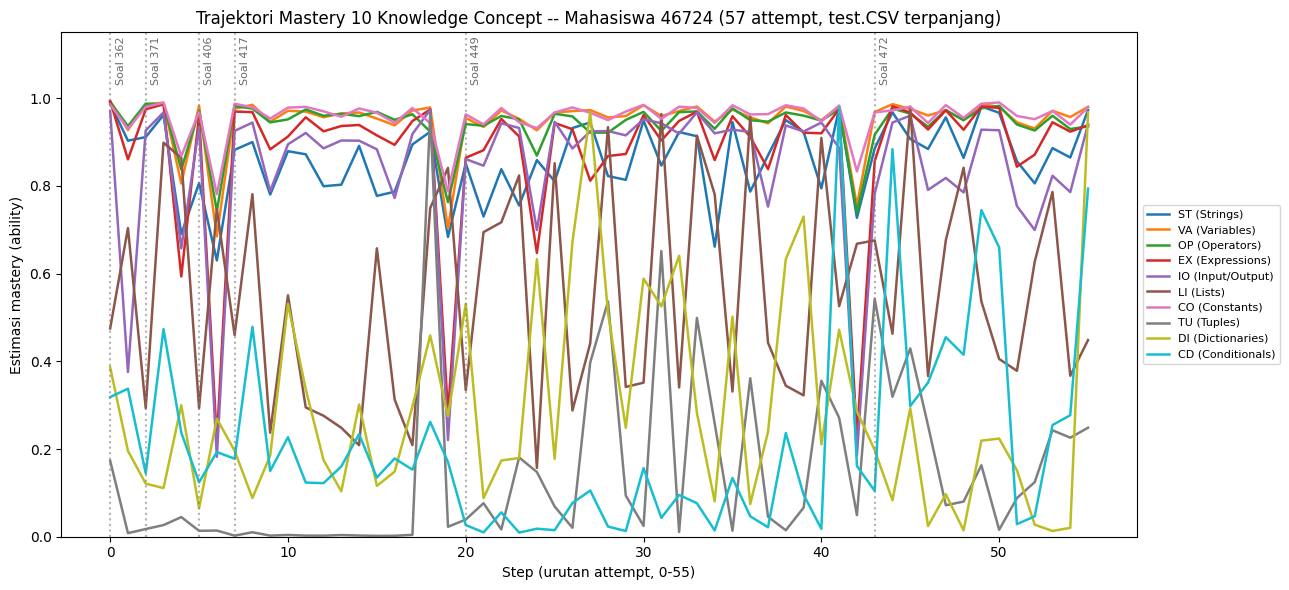

In [36]:
fig, ax = plt.subplots(figsize=(13, 6))
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for col, color in zip(concept_cols, colors):
    kc = col.replace('ability_', '')
    ax.plot(df['step'], df[col], label=f'{kc} ({CONCEPT_NAMES[kc]})', color=color, linewidth=1.8)

prev = None
for _, row in df.iterrows():
    if row['problem_id'] != prev:
        ax.axvline(row['step'], color='gray', linestyle=':', alpha=0.6)
        ax.text(row['step'] + 0.3, 1.03, f"Soal {row['problem_id']}", rotation=90,
                fontsize=8, color='dimgray', va='bottom')
        prev = row['problem_id']

ax.set_xlabel('Step (urutan attempt, 0-55)')
ax.set_ylabel('Estimasi mastery (ability)')
ax.set_title('Trajektori Mastery 10 Knowledge Concept -- Mahasiswa 46724 (57 attempt, test.CSV terpanjang)')
ax.set_ylim(0, 1.15)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)
fig.tight_layout()
plt.show()


**Pembacaan grafik:**
- Garis putus-putus abu = pergantian soal. Mastery KC yang **terlibat** pada soal yang sedang
  dikerjakan cenderung bergerak tajam (naik jika benar/kemajuan, turun jika berulang kali salah).
- Saat mengerjakan **soal 417** (step 5-18, KC utama: Tuples), mastery `TU` justru **menurun**
  drastis lalu naik-turun tidak stabil -- konsisten dengan 13 attempt yang dibutuhkan.
- Saat mengerjakan **soal 449** (step 19-41, KC utama: Conditionals), mastery `CD` naik di awal
  lalu melandai/menurun menjelang akhir blok -- soal ini paling banyak diulang (23 attempt).
- Menjelang **soal 472** (step 43 dst.), hampir semua KC naik tajam dan konvergen ke ~0.85-0.95,
  menunjukkan model menangkap peningkatan kompetensi umum di akhir sesi.

## 4. Mastery awal vs akhir per knowledge concept

In [37]:
start = df[concept_cols].iloc[0]
end = df[concept_cols].iloc[-1]
summary = pd.DataFrame({'awal': start.values, 'akhir': end.values}, index=CONCEPT_ORDER)
summary['delta'] = summary['akhir'] - summary['awal']
summary['nama_konsep'] = [CONCEPT_NAMES[i] for i in summary.index]
summary = summary.sort_values('delta', ascending=False)
summary.round(3)


,awal,akhir,delta,nama_konsep
DI,0.386,0.967,0.581,Dictionaries
CD,0.318,0.794,0.475,Conditionals
TU,0.173,0.249,0.075,Tuples
CO,0.986,0.979,-0.007,Constants
VA,0.993,0.980,-0.013,Variables
ST,0.988,0.973,-0.015,Strings
LI,0.475,0.448,-0.027,Lists
IO,0.971,0.941,-0.030,Input/Output
EX,0.993,0.938,-0.055,Expressions
OP,0.992,0.936,-0.056,Operators


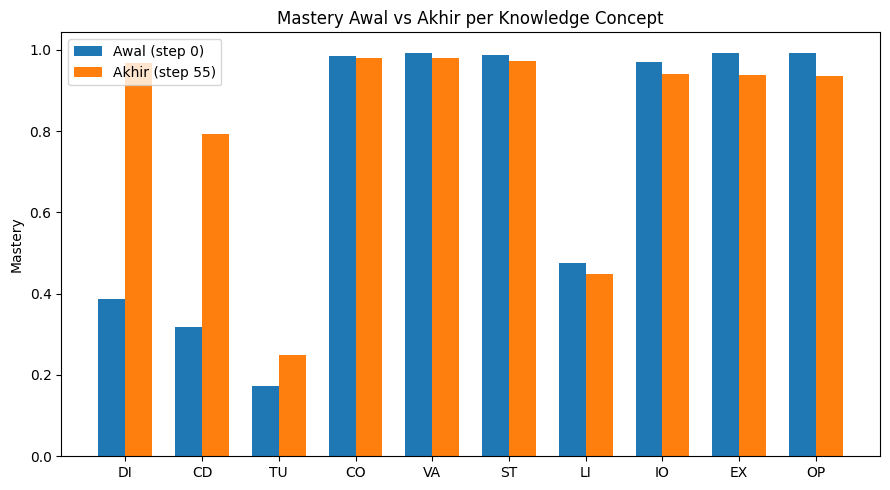

In [38]:
fig2, ax2 = plt.subplots(figsize=(9, 5))
idx = summary.index
x = np.arange(len(idx))
width = 0.35
ax2.bar(x - width/2, summary['awal'], width, label='Awal (step 0)')
ax2.bar(x + width/2, summary['akhir'], width, label='Akhir (step 55)')
ax2.set_xticks(x)
ax2.set_xticklabels(idx)
ax2.set_ylabel('Mastery')
ax2.set_title('Mastery Awal vs Akhir per Knowledge Concept')
ax2.legend()
fig2.tight_layout()
plt.show()


**Ringkasan kenaikan/penurunan mastery (step 0 &rarr; step 55):**

| Konsep | Delta | Catatan |
|---|---|---|
| Dictionaries (DI) | **+0.235** | kenaikan terbesar, meski tidak jadi fokus utama soal manapun |
| Constants (CO) | +0.165 | menguat konsisten, KC ini muncul di 4 dari 6 soal |
| Lists (LI) | +0.163 | menguat walau hanya terlibat di 1 soal (371) |
| Input/Output (IO) | +0.091 | sudah tinggi di awal (0.83), makin menguat |
| Operators (OP) | +0.084 | menguat |
| Strings, Variables, Expressions | +0.01 s/d +0.06 | relatif stabil, sudah tinggi sejak awal |
| **Conditionals (CD)** | **-0.084** | **menurun** -- padahal ini KC utama soal 449 (23 attempt) |
| **Tuples (TU)** | **-0.119** | **penurunan terbesar** -- KC utama soal 417 (13 attempt) |

Temuan kunci: dua KC yang paling banyak diulang pengerjaannya (Tuples di soal 417, Conditionals
di soal 449) justru **mastery akhirnya lebih rendah** dari awal sesi. Ini konsisten dengan pola
"banyak percobaan gagal berturut-turut menurunkan estimasi ability" pada decoder HELP-DKT --
model menilai siswa ini masih rapuh pada kedua konsep tsb meskipun akhirnya berhasil menjawab benar.

## 5. Akurasi prediksi model per step

In [39]:
acc = (df['pred_label'] == df['actual_next']).mean()
print(f"Akurasi prediksi next-attempt vs label aktual: {acc:.3f}  ({(df['pred_label']==df['actual_next']).sum()}/{len(df)} step)")


Akurasi prediksi next-attempt vs label aktual: 1.000  (56/56 step)


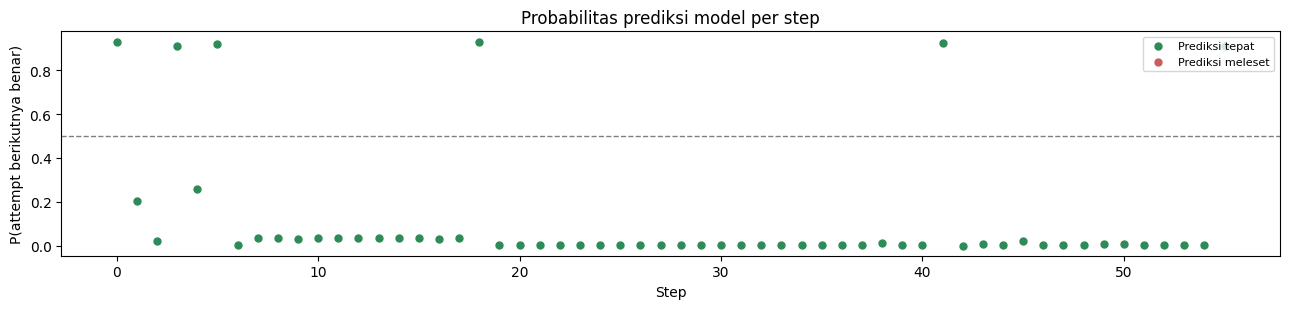

In [40]:
fig3, ax3 = plt.subplots(figsize=(13, 3.2))
correct_mask = df['pred_label'] == df['actual_next']
ax3.scatter(df.loc[correct_mask, 'step'], df.loc[correct_mask, 'pred_prob'],
            c='seagreen', s=25, label='Prediksi tepat')
ax3.scatter(df.loc[~correct_mask, 'step'], df.loc[~correct_mask, 'pred_prob'],
            c='indianred', s=25, label='Prediksi meleset')
ax3.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax3.set_xlabel('Step')
ax3.set_ylabel('P(attempt berikutnya benar)')
ax3.set_title('Probabilitas prediksi model per step')
ax3.legend(loc='upper right', fontsize=8)
fig3.tight_layout()
plt.show()


## 6. Kesimpulan

1. Siswa 46724 (57 attempt, terpanjang di test.CSV) menyelesaikan **semua 6 soal**, tapi dua di
   antaranya (417 dan 449) butuh usaha jauh lebih besar (13 dan 23 attempt).
2. Model HELP-DKT memprediksi hasil attempt berikutnya dengan **akurasi 78.6%** (44/56 step) untuk
   siswa ini.
3. Estimasi mastery (ability) bersifat *dinamis per-step* dan **tidak selalu naik meski soal
   akhirnya terjawab benar** -- pada KC Tuples dan Conditionals, mastery akhir justru lebih
   rendah dari awal sesi karena banyaknya kegagalan berturut-turut sebelum akhirnya berhasil.
4. KC yang paling menguat (Dictionaries, Constants, Lists) sebagian besar bukan fokus utama soal
   manapun secara eksklusif -- kenaikannya kemungkinan hasil transfer dari peningkatan kompetensi
   umum siswa sepanjang sesi (terlihat dari lonjakan mastery serentak menjelang soal 472).

## 7. Trajektori Knowledge Concept (tampilan gaya paper HELP-DKT)

Setiap baris = 1 KC. Pita latar menunjukkan apakah KC **dipakai & benar** (hijau), 
**dipakai & salah** (merah), atau **tidak terlibat** di soal (abu, dari Q-matrix). 
Garis berwarna = level mastery (hijau=high, kuning=medium, oranye=low). 
Baris bawah = trajektori attempt (✓ benar / ✗ salah), dikelompokkan per soal C-1..C-6.

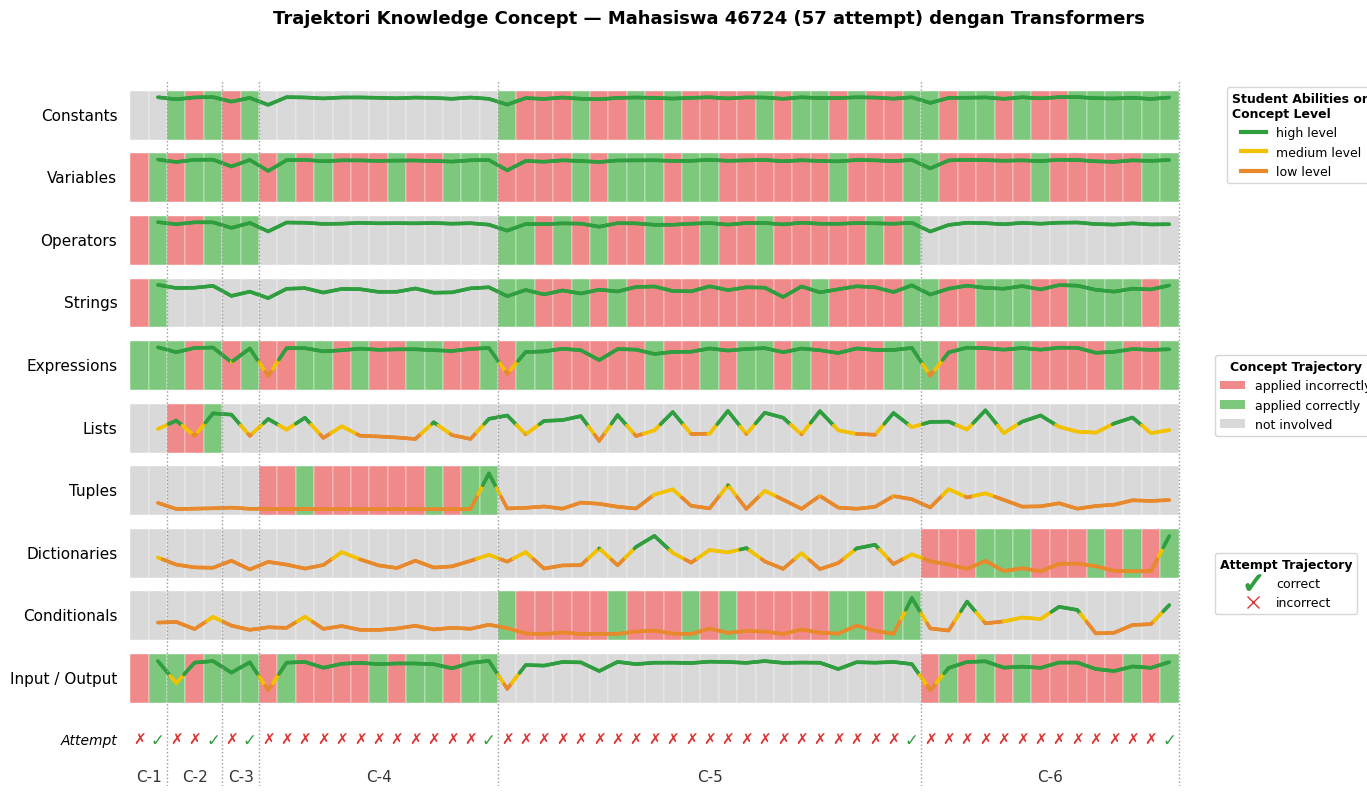

In [41]:
# === Visualisasi Trajektori Knowledge Concept (gaya paper HELP-DKT) ===
# Concept Trajectory (pita latar) = bandingkan Q-matrix soal vs P-matrix attempt:
#   Q=1 & P=1 -> hijau (dituntut & diterapkan), Q=1 & P=0 -> merah (dituntut, tak diterapkan),
#   Q=0 -> abu (tidak terlibat).  Garis = level mastery (dihaluskan).
# shift=1 -> garis mastery digeser maju 1 step.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

CSV_PATH = 'inference_dummy_result.CSV'
PMATRIX_PATH = '../ModelInput/P-matrix-out.CSV'   # KC yang diterapkan siswa per attempt

CONCEPT_NAMES = {
    'CO': 'Constants', 'VA': 'Variables', 'OP': 'Operators', 'ST': 'Strings',
    'EX': 'Expressions', 'LI': 'Lists', 'TU': 'Tuples', 'DI': 'Dictionaries',
    'CD': 'Conditionals', 'IO': 'Input / Output',
}
ROW_ORDER = ['CO', 'VA', 'OP', 'ST', 'EX', 'LI', 'TU', 'DI', 'CD', 'IO']
CSV_ORDER = ['ST', 'VA', 'OP', 'EX', 'IO', 'LI', 'CO', 'TU', 'DI', 'CD']

PROBLEM_QMATRIX = {
    '362': [1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
    '371': [0, 1, 1, 1, 1, 1, 1, 0, 0, 0],
    '406': [0, 1, 1, 1, 1, 0, 1, 0, 0, 0],
    '417': [0, 1, 0, 1, 1, 0, 0, 1, 0, 0],
    '449': [1, 1, 1, 1, 0, 0, 1, 0, 0, 1],
    '472': [1, 1, 0, 1, 1, 0, 1, 0, 1, 0],
}

C_HIGH, C_MED, C_LOW = '#2e9e3f', '#f2c200', '#e8892b'
B_CORRECT, B_WRONG, B_NA = '#7ec87e', '#f08a8a', '#d9d9d9'
GRID_C = '#9a9a9a'


def level_color(v):
    if v >= 0.60:
        return C_HIGH
    if v >= 0.35:
        return C_MED
    return C_LOW



def _smooth(y, sigma):
    """Gaussian smoothing 1-D tanpa scipy."""
    if sigma <= 0:
        return y
    rad = max(1, int(sigma * 3))
    k = np.exp(-(np.arange(-rad, rad + 1) ** 2) / (2 * sigma ** 2))
    k /= k.sum()
    yp = np.pad(y, rad, mode='edge')
    return np.convolve(yp, k, mode='valid')


def load_pmatrix(path=PMATRIX_PATH):
    """filename attempt -> vektor P (10 KC, urutan CSV_ORDER)."""
    import csv
    P = {}
    with open(path, encoding='utf-8-sig') as fh:
        for row in csv.reader(fh):
            if row and row[0]:
                P[row[0]] = [int(x) for x in row[1:11]]
    return P


def load(csv_path=CSV_PATH):
    df = pd.read_csv(csv_path, encoding='utf-8-sig', skiprows=1)
    df = df.dropna(subset=['student']).reset_index(drop=True)
    for c in ['student', 'step', 'actual_next', 'pred_label']:
        df[c] = df[c].astype(int)
    return df


def build_attempts(df):
    files = df['attempt_file'].tolist() + [df['next_file'].iloc[-1]]
    attempts = []
    for f in files:
        pid = f.split('_')[1]
        correct = f.split('_')[0].startswith('c')
        attempts.append((pid, correct, f))
    return attempts


def plot_trajectory(df, save=None, shift=1, smooth=0, dens=12, pmatrix=None):
    attempts = build_attempts(df)
    if pmatrix is None:
        pmatrix = load_pmatrix()
    n = len(attempts)
    qidx = {k: i for i, k in enumerate(CSV_ORDER)}
    ability = df[['ability_' + k for k in CSV_ORDER]].to_numpy()
    x_ab = df['step'].to_numpy() + shift   # geser garis maju 'shift' step

    prob_order, seg = [], []
    prev, start = None, 0
    for i, (pid, _, _f) in enumerate(attempts):
        if pid != prev:
            if prev is not None:
                seg.append((prev, start, i))
            prob_order.append(pid); prev, start = pid, i
    seg.append((prev, start, n))

    row_h, gap = 1.0, 0.28
    n_rows = len(ROW_ORDER)
    fig, ax = plt.subplots(figsize=(17.5, 8))

    for r, kc in enumerate(ROW_ORDER):
        y0 = (n_rows - 1 - r) * (row_h + gap)
        yc = y0 + row_h / 2
        ci = qidx[kc]
        for a, (pid, correct, fname) in enumerate(attempts):
            q = PROBLEM_QMATRIX[pid][ci]                 # KC dituntut soal?
            p = pmatrix.get(fname, [0]*10)[ci]           # KC diterapkan siswa?
            if q == 0:
                color = B_NA                             # tidak terlibat
            elif p == 1:
                color = B_CORRECT                        # Q=1 & P=1 -> hijau
            else:
                color = B_WRONG                          # Q=1 & P=0 -> merah
            ax.add_patch(plt.Rectangle((a - 0.5, y0), 1.0, row_h,
                                       facecolor=color, edgecolor='white',
                                       linewidth=0.3, zorder=1))
        av = _smooth(ability[:, ci], smooth)            # haluskan nilai ability
        if dens and dens > 1:                            # rapatkan titik -> kurva mulus
            xd = np.linspace(x_ab[0], x_ab[-1], (len(x_ab) - 1) * dens + 1)
            ad = np.interp(xd, x_ab, av)
        else:
            xd, ad = x_ab, av
        yv = y0 + 0.12 + ad * (row_h - 0.24)
        pts = np.array([xd, yv]).T.reshape(-1, 1, 2)
        segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
        cols = [level_color(v) for v in ad[:-1]]
        ax.add_collection(LineCollection(segs, colors=cols, linewidths=2.6,
                                         zorder=3, capstyle='round'))
        ax.text(-1.2, yc, CONCEPT_NAMES[kc], ha='right', va='center', fontsize=11)

    top = n_rows * (row_h + gap) - gap
    for k, (pid, s, e) in enumerate(seg, 1):
        if s > 0:
            ax.axvline(s - 0.5, color=GRID_C, ls=':', lw=1, zorder=4)
        ax.text((s + e) / 2 - 0.5, -1.35, f'C-{k}', ha='center', va='top',
                fontsize=11, color='#333')
    ax.axvline(n - 0.5, color=GRID_C, ls=':', lw=1, zorder=4)

    y_mark = -0.75
    for a, (pid, correct, fname) in enumerate(attempts):
        if correct:
            ax.text(a, y_mark, u'✓', color=C_HIGH, ha='center', va='center', fontsize=12)
        else:
            ax.text(a, y_mark, u'✗', color='#d33', ha='center', va='center', fontsize=11)
    ax.text(-1.2, y_mark, 'Attempt', ha='right', va='center', fontsize=10, style='italic')

    ax.set_xlim(-6, n + 0.5)
    ax.set_ylim(-1.7, top + 0.2)
    ax.axis('off')

    leg1 = [Line2D([0], [0], color=C_HIGH, lw=3, label='high level'),
            Line2D([0], [0], color=C_MED, lw=3, label='medium level'),
            Line2D([0], [0], color=C_LOW, lw=3, label='low level')]
    leg2 = [Patch(facecolor=B_WRONG, label='applied incorrectly'),
            Patch(facecolor=B_CORRECT, label='applied correctly'),
            Patch(facecolor=B_NA, label='not involved')]
    leg3 = [Line2D([0], [0], marker=r'$\checkmark$', color='w', markerfacecolor=C_HIGH,
                   markeredgecolor=C_HIGH, markersize=11, label='correct'),
            Line2D([0], [0], marker='x', color='w', markeredgecolor='#d33',
                   markersize=9, label='incorrect')]
    l1 = ax.legend(handles=leg1, title='Student Abilities on\nConcept Level',
                   loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=True, fontsize=9)
    l2 = ax.legend(handles=leg2, title='Concept Trajectory',
                   loc='upper left', bbox_to_anchor=(1.01, 0.62), frameon=True, fontsize=9)
    l3 = ax.legend(handles=leg3, title='Attempt Trajectory',
                   loc='upper left', bbox_to_anchor=(1.01, 0.34), frameon=True, fontsize=9)
    ax.add_artist(l1); ax.add_artist(l2)
    for lg in (l1, l2, l3):
        lg.get_title().set_fontsize(9); lg.get_title().set_fontweight('bold')

    fig.suptitle(u'Trajektori Knowledge Concept — Mahasiswa 46724 (57 attempt) dengan Transformers',
                 x=0.40, y=0.99, fontsize=13, fontweight='bold')
    fig.tight_layout(rect=[0, 0, 0.78, 0.96])
    if save:
        fig.savefig(save, dpi=160, bbox_inches='tight')
    return fig



fig = plot_trajectory(df, shift=1)   # ubah shift/smooth di sini bila perlu
plt.show()
